# Figure Demo

Generate query-specific figures from the answer object. PDF is the default publication-friendly format; PNG is useful for notebook preview.

In [1]:
from pathlib import Path
import os
import sys
import warnings
from IPython.display import display

warnings.filterwarnings("ignore", message="IProgress not found.*")

repo_root = Path.cwd()
if not (repo_root / "src" / "pxfquery").exists() and (repo_root.parent / "src" / "pxfquery").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / "src"))

# Optional: load local environment variables for the LLM provider.
for env_file in [Path.cwd() / ".env", Path.cwd().parent / ".env", Path.home() / ".env"]:
    if env_file.exists():
        for line in env_file.read_text(encoding="utf-8").splitlines():
            line = line.strip()
            if line and not line.startswith("#") and "=" in line:
                key, value = line.split("=", 1)
                os.environ.setdefault(key.strip(), value.strip())

from pxfquery import PxFQuery

pxf = PxFQuery()
print("PxFquery", pxf.version)
resource_status = pxf.resources.status()
resource_info = resource_status.to_dict() if hasattr(resource_status, "to_dict") else dict(resource_status)
print("Resource status:")
print({
    "available": resource_info.get("available"),
    "source": resource_info.get("source"),
    "version": resource_info.get("version"),
    "available_file_count": len(resource_info.get("available_files") or {}),
})


PxFquery 0.5.12.dev0
Resource status:
{'available': True, 'source': 'manifest', 'version': 'v20260628', 'available_file_count': 18}


In [2]:
from pathlib import Path
from IPython.display import Image, display

out_dir = Path("pxfquery_demo_figures")
out_dir.mkdir(exist_ok=True)

question = (
    "For EGFR-driven lung adenocarcinoma models, what functional programs are changed "
    "by EGFR inhibition, and are inflammatory or MAPK-related programs affected?"
)

print("Question:")
print(question)

qdata = pxf.tl.parse(question, top_n=10)
pxf.tl.answer(qdata)
answer = pxf.get.answer(qdata)

print("Figure specifications:")
for spec in answer.figures:
    print("-", spec.get("title"), "|", spec.get("kind"))

Question:
For EGFR-driven lung adenocarcinoma models, what functional programs are changed by EGFR inhibition, and are inflammatory or MAPK-related programs affected?


[Parsing] start


[Parsing] done | mode=forward; context=EGFR-driven lung adenocarcinoma; perturbation=EGFR inhibition; time=1.65s
[Matching] start


[Matching] done | matches=6; time=4.64s
[Matrix] start


[Matrix] done | profiles=6; skipped=0; time=1.00s
[Evidence] start


[Evidence] done | status=ready; time=9.84s


Figure specifications:
- Evidence Match Map | evidence_match_map
- Functional Signal Clustered By Evidence Match | function_match_heatmap
- Functional Program Evidence Support | function_consensus_bar


In [3]:
pxf.tl.figures(qdata, output_dir=out_dir / "pdf", format="pdf")
print("PDF files:")
for path in qdata.uns["figure_outputs"]:
    print(path)

PDF files:
pxfquery_demo_figures/pdf/pxfquery_01_evidence_match_map.pdf
pxfquery_demo_figures/pdf/pxfquery_02_function_match_heatmap.pdf
pxfquery_demo_figures/pdf/pxfquery_03_function_consensus_bar.pdf


In [4]:
pxf.tl.figures(qdata, output_dir=out_dir / "png", format="png")
print("PNG files:")
for path in qdata.uns["figure_outputs"]:
    print(path)

PNG files:
pxfquery_demo_figures/png/pxfquery_01_evidence_match_map.png
pxfquery_demo_figures/png/pxfquery_02_function_match_heatmap.png
pxfquery_demo_figures/png/pxfquery_03_function_consensus_bar.png


Preview: pxfquery_demo_figures/png/pxfquery_01_evidence_match_map.png


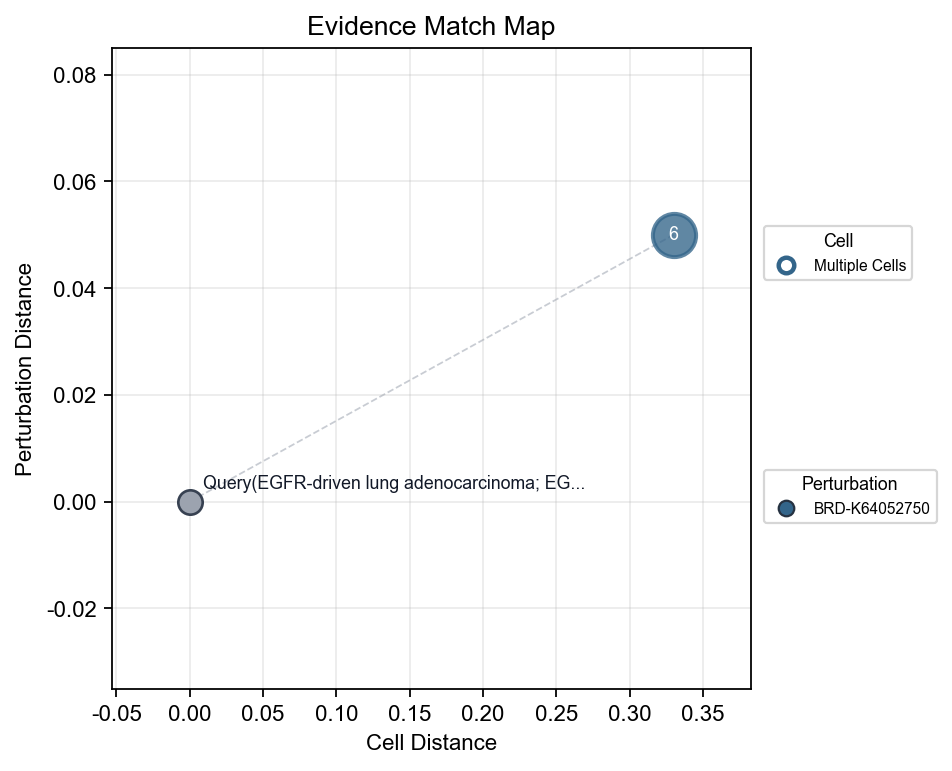

In [5]:
first_png = Path(qdata.uns["figure_outputs"][0])
print("Preview:", first_png)
display(Image(filename=str(first_png)))